### LangGraph  Agent_5: HR Leave Policy Assistant


Imagine your company recently increased Maternity Leave from 14 to 26 weeks. Without tool calling, a standard LLM might rely on its outdated training data and confidently tell an employee "14 weeks."

With tool calling, the agent recognizes it doesn't have the current facts, invokes get_leave_policy(type="maternity"), and retrieves the corrected 26-week figure from your live HR database.

#### Why this matters:

    Precision: It eliminates guesswork for high-stakes information like legal entitlements.

    Source of Truth: It forces the agent to act as a bridge to your official records rather than a standalone encyclopedia.

The following specialized agent functions as a central reasoning node within a LangGraph workflow, specifically engineered to navigate company regulations. By integrating tool-calling capabilities, the agent dynamically invokes the get_leave_policy function to fetch real-time data on sick, casual, and parental leave, ensuring every employee response is grounded in official documentation.

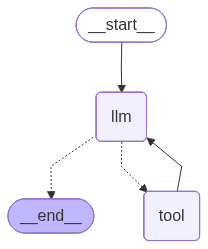

In [1]:
from typing import Literal
from langgraph.graph import StateGraph, END, MessagesState
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import tool



# AWS Bedrock LLM Setup
# ---------------------------
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings #"cohere.command-r-plus-v1:0",
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=500)


@tool
def get_leave_policy(query: str) -> str:
    """Returns company leave policy details."""
    
    query = query.lower()

    if "sick" in query:
        return "Employees get 5 sick leave days per year."
    elif "casual" in query:
        return "Employees get 20 casual leave days annually."
    elif "maternity" in query:
        return "Maternity leave is 26 weeks."
    elif "paternity" in query:
        return "Paternity leave is 5 days."

    return "Please check HR portal for more details."


tools = [get_leave_policy]

tools_by_name = {tool.name: tool for tool in tools}

model_with_tools = llm.bind_tools(tools)

# ---------------------------
# LLM Node
# ---------------------------
def call_llm(state: MessagesState):

    print("STATE MESSAGES:", state["messages"])

    response = model_with_tools.invoke(state["messages"])

    return {"messages": [response]}


# ---------------------------
# Tool Node
# ---------------------------
def call_tool(state: MessagesState):

    last_message = state["messages"][-1]

    tool_call = last_message.tool_calls[0]   

    tool = tools_by_name[tool_call["name"]]

    tool_response = tool.invoke(tool_call["args"])

    return {
        "messages": [
            ToolMessage(
                content=tool_response,
                tool_call_id=tool_call["id"]
            )
        ]
    }


# ---------------------------
# Router
# ---------------------------

def should_continue(state: MessagesState) -> Literal["tool", END]:

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tool"

    return END


# ---------------------------
# Graph
# ---------------------------
builder = StateGraph(MessagesState)

builder.add_node("llm", call_llm)
builder.add_node("tool", call_tool)

builder.set_entry_point("llm")

builder.add_conditional_edges(
    "llm",
    should_continue,
    {
        "tool": "tool",
        END: END
    }
)

builder.add_edge("tool", "llm")

graph = builder.compile()
builder.compile()



In [2]:
from rich import print

# ---------------------------
# Run
# ---------------------------
result = graph.invoke({
    "messages": [
        HumanMessage(content="How many sick and maternity leave weeks do employees get?")
    ]
})


print("\nFINAL ANSWER:")
print(result["messages"][-1].content)

STATE MESSAGES:
[
    HumanMessage(
        content='How many sick and maternity leave weeks do employees get?',
        additional_kwargs={},
        response_metadata={},
        id='4addbf5e-e85f-497c-9409-c96c37ae03ac'
    )
]

STATE MESSAGES:
[
    HumanMessage(
        content='How many sick and maternity leave weeks do employees get?',
        additional_kwargs={},
        response_metadata={},
        id='4addbf5e-e85f-497c-9409-c96c37ae03ac'
    ),
    AIMessage(
        content=[
            {
                'type': 'text',
                'text': '<thinking>I need to use the "get_leave_policy" tool to find out the number of sick and 
maternity leave weeks employees get. I will call this tool with the appropriate query.</thinking>\n'
            },
            {
                'type': 'tool_use',
                'name': 'get_leave_policy',
                'input': {'query': 'How many sick and maternity leave weeks do employees get?'},
                'id': 'tooluse_gLdZAolxVwjIfSpAcWzez5'
            }
        ],
        additional_kwargs={},
        response_metadata={
            'ResponseMetadata': {
                'RequestId': '820c9c0e-d9ef-43af-88ae-fb8d5d2bf0ae',
                'HTTPStatusCode': 200,
                'HTTPHeaders': {
                    'date': 'Sun, 12 Apr 2026 06:07:22 GMT',
                    'content-type': 'application/json',
                    'content-length': '555',
                    'connection': 'keep-alive',
                    'x-amzn-requestid': '820c9c0e-d9ef-43af-88ae-fb8d5d2bf0ae'
                },
                'RetryAttempts': 0
            },
            'stopReason': 'tool_use',
            'metrics': {'latencyMs': [801]},
            'model_provider': 'bedrock_converse',
            'model_name': 'amazon.nova-lite-v1:0'
        },
        id='lc_run--019d804d-4665-78e0-9ce6-2d05285b00db-0',
        tool_calls=[
            {
                'name': 'get_leave_policy',
                'args': {'query': 'How many sick and maternity leave weeks do employees get?'},
                'id': 'tooluse_gLdZAolxVwjIfSpAcWzez5',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={
            'input_tokens': 403,
            'output_tokens': 71,
            'total_tokens': 474,
            'input_token_details': {'cache_creation': 0, 'cache_read': 0}
        }
    ),
    ToolMessage(
        content='Employees get 5 sick leave days per year.',
        id='567ed54c-30c7-41ae-b19b-473465813e9f',
        tool_call_id='tooluse_gLdZAolxVwjIfSpAcWzez5'
    )
]

FINAL ANSWER:

<thinking>The tool has returned information about sick leave but did not provide information about maternity leave.
I will need to ask the user to clarify or provide more information about maternity leave.</thinking>

Hi, I found out that employees get 5 sick leave days per year. However, I did not find information about maternity 
leave. Can you please provide more details about the maternity leave policy?

In [3]:
print(result)

{
    'messages': [
        HumanMessage(
            content='How many sick and maternity leave weeks do employees get?',
            additional_kwargs={},
            response_metadata={},
            id='4addbf5e-e85f-497c-9409-c96c37ae03ac'
        ),
        AIMessage(
            content=[
                {
                    'type': 'text',
                    'text': '<thinking>I need to use the "get_leave_policy" tool to find out the number of sick and
maternity leave weeks employees get. I will call this tool with the appropriate query.</thinking>\n'
                },
                {
                    'type': 'tool_use',
                    'name': 'get_leave_policy',
                    'input': {'query': 'How many sick and maternity leave weeks do employees get?'},
                    'id': 'tooluse_gLdZAolxVwjIfSpAcWzez5'
                }
            ],
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': '820c9c0e-d9ef-43af-88ae-fb8d5d2bf0ae',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Sun, 12 Apr 2026 06:07:22 GMT',
                        'content-type': 'application/json',
                        'content-length': '555',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': '820c9c0e-d9ef-43af-88ae-fb8d5d2bf0ae'
                    },
                    'RetryAttempts': 0
                },
                'stopReason': 'tool_use',
                'metrics': {'latencyMs': [801]},
                'model_provider': 'bedrock_converse',
                'model_name': 'amazon.nova-lite-v1:0'
            },
            id='lc_run--019d804d-4665-78e0-9ce6-2d05285b00db-0',
            tool_calls=[
                {
                    'name': 'get_leave_policy',
                    'args': {'query': 'How many sick and maternity leave weeks do employees get?'},
                    'id': 'tooluse_gLdZAolxVwjIfSpAcWzez5',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 403,
                'output_tokens': 71,
                'total_tokens': 474,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0}
            }
        ),
        ToolMessage(
            content='Employees get 5 sick leave days per year.',
            id='567ed54c-30c7-41ae-b19b-473465813e9f',
            tool_call_id='tooluse_gLdZAolxVwjIfSpAcWzez5'
        ),
        AIMessage(
            content='<thinking>The tool has returned information about sick leave but did not provide information 
about maternity leave. I will need to ask the user to clarify or provide more information about maternity 
leave.</thinking>\n\nHi, I found out that employees get 5 sick leave days per year. However, I did not find 
information about maternity leave. Can you please provide more details about the maternity leave policy?',
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': '21baa7e4-ef12-43a4-92ed-b9fb5fab91f4',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Sun, 12 Apr 2026 06:07:23 GMT',
                        'content-type': 'application/json',
                        'content-length': '615',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': '21baa7e4-ef12-43a4-92ed-b9fb5fab91f4'
                    },
                    'RetryAttempts': 0
                },
                'stopReason': 'end_turn',
                'metrics': {'latencyMs': [710]},
                'model_provider': 'bedrock_converse',
                'model_name': 'amazon.nova-lite-v1:0'
            },
            id='lc_run--019d804d-4c3c-78a3-a0b7-2b1fb1be51

In [ ]:
# #Tools
 Prebulit Package LangGraph

    ToolNode
    create_react_agent, 
    ToolNode, 
    supervisor agent,
    Validation Node, 


## With Tool Node

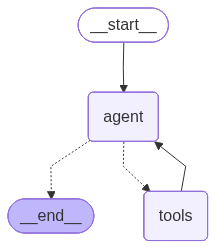

In [5]:
from langgraph.graph import StateGraph, END, MessagesState

from langgraph.prebuilt import ToolNode

from langchain_core.messages import HumanMessage
from langchain_core.tools import tool



# AWS Bedrock LLM Setup
# ---------------------------
from langchain_aws import ChatBedrockConverse
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id="cohere.command-r-plus-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=500)

# ---------------------------
# Tool
# ---------------------------
# ---------------------------
# Tool
# ---------------------------
@tool
def get_leave_policy(query: str) -> str:
    """Returns company leave policy details."""

    query = query.lower()

    if "sick" in query:
        return "Employees get 5 sick leave days per year."
    elif "casual" in query:
        return "Employees get 20 casual leave days annually."
    elif "maternity" in query:
        return "Maternity leave is 26 weeks."
    elif "paternity" in query:
        return "Paternity leave is 5 days."

    return "Please check HR portal for more details."

tools = [get_leave_policy]

llm_with_tools = llm.bind_tools(tools)

# ---------------------------
# Agent Node
# ---------------------------
def agent_node(state: MessagesState):

    response = llm_with_tools.invoke(state["messages"])

    return {"messages": [response]}


# ---------------------------
# Tool Node
# ---------------------------
tool_node = ToolNode(tools)

# def call_tool(state: MessagesState):

#     last_message = state["messages"][-1]

#     tool_call = last_message.tool_calls[0]   

#     tool = tools_by_name[tool_call["name"]]

#     tool_response = tool.invoke(tool_call["args"])

#     return {
#         "messages": [
#             ToolMessage(
#                 content=tool_response,
#                 tool_call_id=tool_call["id"]
#             )
#         ]
#     }



# ---------------------------
# Router (decide tool or end)
# ---------------------------
def should_continue(state: MessagesState):

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return END


# ---------------------------
# Build Graph
# ---------------------------
builder = StateGraph(MessagesState)

builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)

builder.set_entry_point("agent")

builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        END: END
    }
)

builder.add_edge("tools", "agent")

graph = builder.compile()
builder.compile()



In [6]:
result = graph.invoke({
    "messages": [
        HumanMessage(content="How many sick leaves do employees get in total in a year?")
    ]
},)

print(result["messages"][-1].content)

Employees get 5 sick leave days per year.

In [7]:
from rich import print
print(result)

{
    'messages': [
        HumanMessage(
            content='How many sick leaves do employees get in total in a year?',
            additional_kwargs={},
            response_metadata={},
            id='27b63d89-32bf-4c02-b340-a37c5506c93f'
        ),
        AIMessage(
            content=[
                {'type': 'text', 'text': 'I will search for the number of sick leaves employees get in a year.'},
                {
                    'type': 'tool_use',
                    'name': 'get_leave_policy',
                    'input': {'query': 'sick leave'},
                    'id': 'tooluse_a9XbWXTHynrqiNwZ0EWT3i'
                }
            ],
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': '874f34e5-26bf-45ed-af1c-75cf680484be',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Tue, 10 Mar 2026 03:13:43 GMT',
                        'content-type': 'application/json',
                        'content-length': '387',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': '874f34e5-26bf-45ed-af1c-75cf680484be'
                    },
                    'RetryAttempts': 0
                },
                'stopReason': 'tool_use',
                'metrics': {'latencyMs': [1925]},
                'model_name': 'cohere.command-r-plus-v1:0'
            },
            id='run--db5050ce-b2a1-4b3f-b4aa-5a65fda07864-0',
            tool_calls=[
                {
                    'name': 'get_leave_policy',
                    'args': {'query': 'sick leave'},
                    'id': 'tooluse_a9XbWXTHynrqiNwZ0EWT3i',
                    'type': 'tool_call'
                }
            ],
            usage_metadata={
                'input_tokens': 25,
                'output_tokens': 27,
                'total_tokens': 52,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0}
            }
        ),
        ToolMessage(
            content='Employees get 5 sick leave days per year.',
            name='get_leave_policy',
            id='334c0c1c-cbbc-4fef-82c8-882194a3e90b',
            tool_call_id='tooluse_a9XbWXTHynrqiNwZ0EWT3i'
        ),
        AIMessage(
            content='Employees get 5 sick leave days per year.',
            additional_kwargs={},
            response_metadata={
                'ResponseMetadata': {
                    'RequestId': '80a6a29e-2548-4c9f-aaa7-65b49940906b',
                    'HTTPStatusCode': 200,
                    'HTTPHeaders': {
                        'date': 'Tue, 10 Mar 2026 03:13:45 GMT',
                        'content-type': 'application/json',
                        'content-length': '244',
                        'connection': 'keep-alive',
                        'x-amzn-requestid': '80a6a29e-2548-4c9f-aaa7-65b49940906b'
                    },
                    'RetryAttempts': 0
                },
                'stopReason': 'end_turn',
                'metrics': {'latencyMs': [1620]},
                'model_name': 'cohere.command-r-plus-v1:0'
            },
            id='run--ad846300-3e43-4fc8-9d13-4e92a319b069-0',
            usage_metadata={
                'input_tokens': 62,
                'output_tokens': 10,
                'total_tokens': 72,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0}
            }
        )
    ]
}